importamo en file

In [23]:
import pandas as pd

df = pd.read_csv("2024_03_Planica_12_winds/999_999_Jumper_Anon_ANO_1_20240409-102833_C_OfficialResults.csv", sep=';', decimal=',')


## Priprava podatkov

In [24]:
TAB1 = df
TAB1

,Position,Height above ground [m],Time,X [m],Y [m],Z [m],Opening Angle [°],Stalling Angle Left [°],Stalling Angle Right [°],Roll Angle Left [°],Roll Angle Right [°],Yaw Angle Left [°],Yaw Angle Right [°],Speed hor. [km/h],Speed vert. [km/h],Speed resulting [km/h],WindTime|WindName|WindSpeed|WindSpeedTangent|WindTurbulence|WindSpeedCleanTan|WindSpeedCross
0,-95.09,NaN,0001-01-01T00:00:00.0000000+01:00,-82.57,0.00,44.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0001-01-01T00:00:00.097+01:00|W1|0.7|0.53|0.02...
1,0.00,2.93,0001-01-01T00:00:04.1720000+01:00,0.03,0.00,-0.01,0.0,-11.500,-11.500,0.000,0.000,0.000,0.000,97.169,-19.769,99.159,0001-01-01T00:00:04.098+01:00|W1|1.1|-0.01|0.3...
2,1.00,2.89,0001-01-01T00:00:04.3690000+01:00,1.34,-0.02,-0.20,2.6,-10.160,-9.546,2.687,-1.630,1.223,-1.380,95.431,-12.424,96.240,0001-01-01T00:00:04.348+01:00|W1|1.4|0.06|0.58...
3,2.00,2.91,0001-01-01T00:00:04.4080000+01:00,2.38,-0.03,-0.32,4.1,-8.028,-7.168,3.455,-2.842,1.953,-2.203,95.220,-10.811,95.837,0001-01-01T00:00:04.348+01:00|W1|1.4|0.06|0.58...
4,3.00,2.95,0001-01-01T00:00:04.4470000+01:00,3.42,-0.04,-0.44,6.2,-5.084,-4.289,5.605,-6.534,2.896,-3.278,96.284,-10.482,96.856,0001-01-01T00:00:04.348+01:00|W1|1.4|0.06|0.58...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,210.00,0.27,0001-01-01T00:00:10.8970000+01:00,180.04,0.78,-107.70,7.5,-18.501,-21.099,-9.573,-0.905,0.522,-2.690,106.404,-83.278,135.232,0001-01-01T00:00:10.845+01:00|W1|1.6|-0.23|0.1...
212,211.00,0.16,0001-01-01T00:00:10.9240000+01:00,180.84,0.86,-108.30,6.9,-19.433,-21.592,-8.943,-0.081,-0.056,-2.179,106.257,-83.147,135.028,0001-01-01T00:00:10.845+01:00|W1|1.6|-0.23|0.1...
213,212.00,0.07,0001-01-01T00:00:10.9510000+01:00,181.65,0.94,-108.90,6.4,-20.522,-22.085,-7.980,0.745,-0.512,-1.667,106.076,-82.924,134.736,0001-01-01T00:00:10.845+01:00|W1|1.6|-0.23|0.1...
214,213.00,0.10,0001-01-01T00:00:10.9780000+01:00,182.45,1.02,-109.50,5.9,-21.612,-22.578,-7.016,1.571,-0.968,-1.155,105.895,-82.702,134.446,0001-01-01T00:00:11.104+01:00|W1|1.6|-0.21|0.0...


izločimo najbolj problematičen stolpec

In [25]:
wind_col_name = df.columns[-1]
print("Last column:", wind_col_name)
print("Example value:", df[wind_col_name].iloc[0])


Last column: WindTime|WindName|WindSpeed|WindSpeedTangent|WindTurbulence|WindSpeedCleanTan|WindSpeedCross
Example value: 0001-01-01T00:00:00.097+01:00|W1|0.7|0.53|0.02|0.53|0.20;0001-01-01T00:00:00.097+01:00|W2|0.7|0.50|0.24|0.50|0.17;0001-01-01T00:00:00.097+01:00|W3|1.0|0.37|0.14|0.37|0.66;0001-01-01T00:00:00.097+01:00|W4|1.7|-0.68|0.02|-0.68|1.41;0001-01-01T00:00:00.097+01:00|W5|1.2|0.75|0.24|0.75|0.82;0001-01-01T00:00:00.097+01:00|W6|3.2|1.33|0.68|1.33|2.86;0001-01-01T00:00:00.097+01:00|W7|3.2|-0.13|0.31|-0.13|3.24;0001-01-01T00:00:00.097+01:00|W8|2.5|-0.29|0.25|-0.29|2.28;0001-01-01T00:00:00.097+01:00|W9|3.8|-3.31|1.03|-3.31|1.15;0001-01-01T00:00:00.097+01:00|W10|1.1|-1.03|0.13|-1.03|0.41;0001-01-01T00:00:00.097+01:00|W11|0.8|-0.58|0.02|-0.58|0.39;0001-01-01T00:00:00.097+01:00|W12|1.8|1.16|0.19|1.16|1.14


izluščimo podatke o vetru

In [ ]:
from flatten_wind import *

wind_df = df[wind_col_name].apply(flatten_wind_blob)
df_cleaned = pd.concat([df.drop(columns=[wind_col_name]), wind_df], axis=1)

print(df_cleaned.head())

  Position Height above ground [m]                               Time   X [m]  \
0   -95.09                     NaN  0001-01-01T00:00:00.0000000+01:00  -82.57   
1     0.00                    2.93  0001-01-01T00:00:04.1720000+01:00    0.03   
2     1.00                    2.89  0001-01-01T00:00:04.3690000+01:00    1.34   
3     2.00                    2.91  0001-01-01T00:00:04.4080000+01:00    2.38   
4     3.00                    2.95  0001-01-01T00:00:04.4470000+01:00    3.42   

   Y [m]  Z [m] Opening Angle [°] Stalling Angle Left [°]  \
0   0.00  44.03               NaN                     NaN   
1   0.00  -0.01               0.0                 -11.500   
2  -0.02  -0.20               2.6                 -10.160   
3  -0.03  -0.32               4.1                  -8.028   
4  -0.04  -0.44               6.2                  -5.084   

  Stalling Angle Right [°] Roll Angle Left [°]  ... W11_Speed W11_Tangent  \
0                      NaN                 NaN  ...       0.8       -

izluščimo podatke o času

In [ ]:
df_cleaned["Time"] = df_cleaned["Time"].apply(timestamp_to_seconds)

In [29]:
TAB2 = df_cleaned
TAB2

,Position,Height above ground [m],Time,X [m],Y [m],Z [m],Opening Angle [°],Stalling Angle Left [°],Stalling Angle Right [°],Roll Angle Left [°],...,W11_Speed,W11_Tangent,W11_Turbulence,W11_CleanTan,W11_Cross,W12_Speed,W12_Tangent,W12_Turbulence,W12_CleanTan,W12_Cross
0,-95.09,NaN,0.000,-82.57,0.00,44.03,NaN,NaN,NaN,NaN,...,0.8,-0.58,0.02,-0.58,0.39,1.8,1.16,0.19,1.16,1.14
1,0.00,2.93,4.172,0.03,0.00,-0.01,0.0,-11.500,-11.500,0.000,...,1.0,-0.67,0.07,-0.67,0.70,2.2,2.16,0.17,2.16,0.16
2,1.00,2.89,4.369,1.34,-0.02,-0.20,2.6,-10.160,-9.546,2.687,...,1.0,-0.68,0.04,-0.68,0.75,2.2,2.14,0.25,2.14,0.03
3,2.00,2.91,4.408,2.38,-0.03,-0.32,4.1,-8.028,-7.168,3.455,...,1.0,-0.68,0.04,-0.68,0.75,2.2,2.14,0.25,2.14,0.03
4,3.00,2.95,4.447,3.42,-0.04,-0.44,6.2,-5.084,-4.289,5.605,...,1.0,-0.68,0.04,-0.68,0.75,2.2,2.14,0.25,2.14,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,210.00,0.27,10.897,180.04,0.78,-107.70,7.5,-18.501,-21.099,-9.573,...,1.1,-0.86,0.10,-0.86,0.63,2.3,2.14,0.72,2.14,0.63
212,211.00,0.16,10.924,180.84,0.86,-108.30,6.9,-19.433,-21.592,-8.943,...,1.1,-0.86,0.10,-0.86,0.63,2.3,2.14,0.72,2.14,0.63
213,212.00,0.07,10.951,181.65,0.94,-108.90,6.4,-20.522,-22.085,-7.980,...,1.1,-0.86,0.10,-0.86,0.63,2.3,2.14,0.72,2.14,0.63
214,213.00,0.10,10.978,182.45,1.02,-109.50,5.9,-21.612,-22.578,-7.016,...,1.1,-0.86,0.10,-0.86,0.63,2.3,2.18,0.69,2.18,0.51


## Analiza

In [30]:
razpon_visine = f"od {TAB2["Height above ground [m]"].dropna().min()} do {TAB2["Height above ground [m]"].dropna().max()}"
razpon_visine

'od 0.00 do 5.32'

In [ ]:
differences = {}

for idx in range(len(df_cleaned["Time"]) - 1):
    a = df_cleaned["Time"].iloc[idx + 1]
    b = df_cleaned["Time"].iloc[idx]
    r = a - b
    differences[idx] = r

razpon_casa = f"od {min(differences.values())} do {max(differences.values())}"
razpon_casa

#alternativna verzija:
#time_diffs = df_cleaned["Time"].diff().dropna()
#razpon_casa = f"od {time_diffs.min()} do {time_diffs.max()}"
#razpon_casa

'od 0.02200000000000024 do 4.172'

pri nekaterih files dobimo negativno vrednost, zato preverimo stolpec časov

In [ ]:
is_sorted = df_cleaned["Time"].is_monotonic_increasing
print("Is time column sorted?", is_sorted)

Is time column sorted? True


In [ ]:
# Print first few values
print(df_cleaned["Time"].head(10))


float64
0    0.000
1    4.172
2    4.369
3    4.408
4    4.447
5    4.486
6    4.524
7    4.563
8    4.601
9    4.640
Name: Time, dtype: float64


In [35]:
TAB2

,Position,Height above ground [m],Time,X [m],Y [m],Z [m],Opening Angle [°],Stalling Angle Left [°],Stalling Angle Right [°],Roll Angle Left [°],...,W11_Speed,W11_Tangent,W11_Turbulence,W11_CleanTan,W11_Cross,W12_Speed,W12_Tangent,W12_Turbulence,W12_CleanTan,W12_Cross
0,-95.09,NaN,0.000,-82.57,0.00,44.03,NaN,NaN,NaN,NaN,...,0.8,-0.58,0.02,-0.58,0.39,1.8,1.16,0.19,1.16,1.14
1,0.00,2.93,4.172,0.03,0.00,-0.01,0.0,-11.500,-11.500,0.000,...,1.0,-0.67,0.07,-0.67,0.70,2.2,2.16,0.17,2.16,0.16
2,1.00,2.89,4.369,1.34,-0.02,-0.20,2.6,-10.160,-9.546,2.687,...,1.0,-0.68,0.04,-0.68,0.75,2.2,2.14,0.25,2.14,0.03
3,2.00,2.91,4.408,2.38,-0.03,-0.32,4.1,-8.028,-7.168,3.455,...,1.0,-0.68,0.04,-0.68,0.75,2.2,2.14,0.25,2.14,0.03
4,3.00,2.95,4.447,3.42,-0.04,-0.44,6.2,-5.084,-4.289,5.605,...,1.0,-0.68,0.04,-0.68,0.75,2.2,2.14,0.25,2.14,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,210.00,0.27,10.897,180.04,0.78,-107.70,7.5,-18.501,-21.099,-9.573,...,1.1,-0.86,0.10,-0.86,0.63,2.3,2.14,0.72,2.14,0.63
212,211.00,0.16,10.924,180.84,0.86,-108.30,6.9,-19.433,-21.592,-8.943,...,1.1,-0.86,0.10,-0.86,0.63,2.3,2.14,0.72,2.14,0.63
213,212.00,0.07,10.951,181.65,0.94,-108.90,6.4,-20.522,-22.085,-7.980,...,1.1,-0.86,0.10,-0.86,0.63,2.3,2.14,0.72,2.14,0.63
214,213.00,0.10,10.978,182.45,1.02,-109.50,5.9,-21.612,-22.578,-7.016,...,1.1,-0.86,0.10,-0.86,0.63,2.3,2.18,0.69,2.18,0.51


## vizualizacija

### veter
Veter je merjen z 12 senzorji (W1-W12) razporejeni na 3 različne cone po skakalnici.

In [36]:
zones = {
    "takeoff": ["W1_Tangent", "W2_Tangent", "W3_Tangent"],
    "mid":     ["W4_Tangent", "W5_Tangent", "W6_Tangent", "W7_Tangent"],
    "landing": ["W8_Tangent", "W9_Tangent", "W10_Tangent", "W11_Tangent", "W12_Tangent"]
}


naredimo slovar cone in njenega povprečnega vetra v tej coni

In [ ]:
zone_winds = {
    zone: df_cleaned[cols].astype(float).mean(axis=1).mean()
    for zone, cols in zones.items()
}

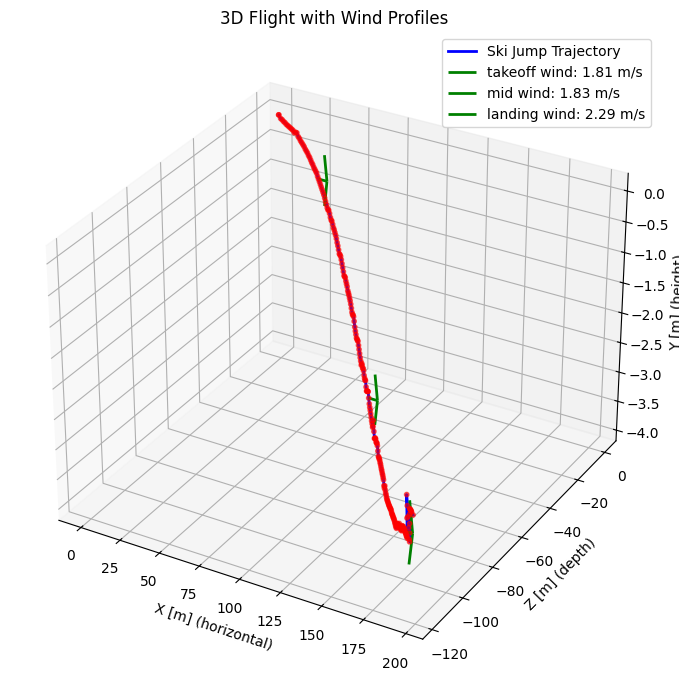

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# določimo koordinate + začetno točko v (0,0,0)
x_data = df_cleaned["X [m]"][1:].astype(float).to_numpy()
y_data = df_cleaned["Y [m]"][1:].astype(float).to_numpy()
z_data = df_cleaned["Z [m]"][1:].astype(float).to_numpy()
x = np.insert(x_data, 0, 0.0)
y = np.insert(y_data, 0, 0.0)
z = np.insert(z_data, 0, 0.0)


#približne lokacije za puščice vetra
n = len(x)
positions = {
    "takeoff": int(n * 0.15),
    "mid":     int(n * 0.5),
    "landing": int(n * 0.85)
}

# plot flight trajectory
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(x, z, y, label='Ski Jump Trajectory', color='blue', linewidth=2)
ax.scatter3D(x, z, y, color='red', s=10, alpha=0.6)

# Plot wind arrows (tangent direction = along X)

for zone, position in positions.items():
    wind = zone_winds[zone]
    ax.quiver(x[position], z[position], y[position],
              1 if wind >= 0 else -1, 0, 0,  # X-direction only
              length=abs(wind) * 3, color='green', linewidth=2,
              label=f'{zone} wind: {wind:.2f} m/s')


ax.set_title("3D Flight with Wind Profiles")
ax.set_xlabel("X [m] (horizontal)")
ax.set_ylabel("Z [m] (depth)")
ax.set_zlabel("Y [m] (height)")
ax.legend()
plt.tight_layout()
plt.show()


Nakateri Y zavzammejo pozitivne vrednosti, poskusimo če sprmenimo.

##### path

In [ ]:
df_cleaned["Y [m]"] = df_cleaned["Y [m]"].astype(float)

# Now safely check and flip if needed
if df_cleaned["Y [m]"].iloc[-1] >= 0:
    df_cleaned["Y [m]"] = -df_cleaned["Y [m]"]
    print("Y column was flipped (now ends with a negative value).")
else:
    print("Y column already ends with a negative value, no change made.")

Y column was flipped (now ends with a negative value).


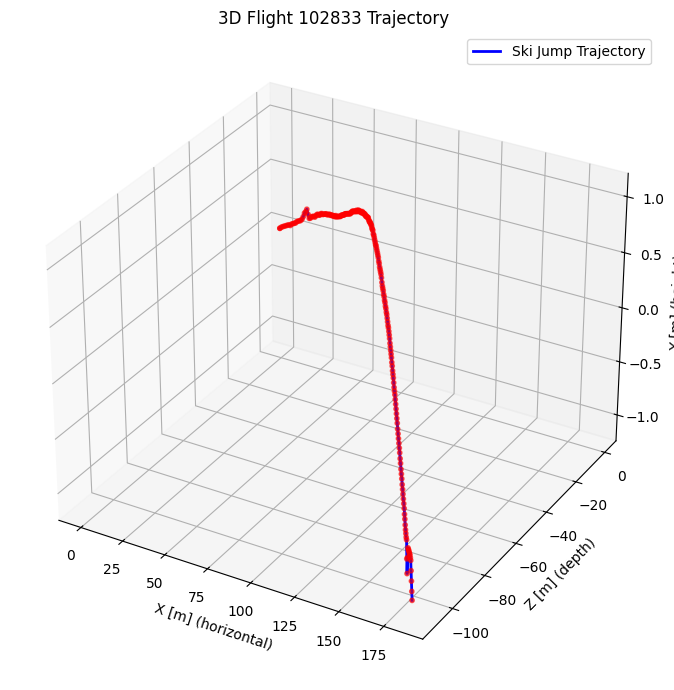

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# koordinate z začetkom v (0, 0, 0)
x_data = df_cleaned["X [m]"][1:].astype(float).to_numpy()
y_data = df_cleaned["Y [m]"][1:].astype(float).to_numpy()
z_data = df_cleaned["Z [m]"][1:].astype(float).to_numpy()
x = np.insert(x_data, 0, 0.0)
y = np.insert(y_data, 0, 0.0)
z = np.insert(z_data, 0, 0.0)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot3D(x, z, y, label='Ski Jump Trajectory', color='blue', linewidth=2)
ax.scatter3D(x, z, y, color='red', s=10, alpha=0.6)

ax.set_title("3D Flight 102833 Trajectory")
ax.set_xlabel("X [m] (horizontal)")
ax.set_ylabel("Z [m] (depth)")
ax.set_zlabel("Y [m] (height)")
ax.legend()
plt.tight_layout()
plt.show()